In [1]:
# 1. Check if an NVIDIA graphics card (GPU) is ready to use
import torch

if torch.cuda.is_available():
    print("GPU is found! Training will be fast.")
    print("Your GPU name is:", torch.cuda.get_device_name(0))
else:
    print("No GPU found. It will run on CPU (this will be slower).")

GPU is found! Training will be fast.
Your GPU name is: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
# 2. Install Ultralytics (YOLO) and PyYAML
!pip install ultralytics pyyaml

train_img_path = "C:\\Users\\sandh\\PycharmProjects\\mlcore\\open model\\dataset\\ANPR.v2i.yolov8\\train\\images"
val_img_path   = "C:\\Users\\sandh\\PycharmProjects\\mlcore\\open model\\dataset\\ANPR.v2i.yolov8\\valid\\images"
test_img_path  = "C:\\Users\\sandh\\PycharmProjects\\mlcore\\open model\\dataset\\ANPR.v2i.yolov8\\test\\images"

In [8]:
import os

train_img_path = r"C:\Users\sandh\PycharmProjects\mlcore\open model\dataset\ANPR.v2i.yolov8\train\images"
val_img_path   = r"C:\Users\sandh\PycharmProjects\mlcore\open model\dataset\ANPR.v2i.yolov8\valid\images"
test_img_path  = r"C:\Users\sandh\PycharmProjects\mlcore\open model\dataset\ANPR.v2i.yolov8\test\images"

# Let's count files to verify paths are correct
print("Checking folders:")
print("Train images found:", len(os.listdir(train_img_path)) if os.path.exists(train_img_path) else "Folder missing!")
print("Val images found:  ", len(os.listdir(val_img_path)) if os.path.exists(val_img_path) else "Folder missing!")
print("Test images found: ", len(os.listdir(test_img_path)) if os.path.exists(test_img_path) else "Folder missing!")

Checking folders:
Train images found: 1350
Val images found:   129
Test images found:  64


existing_yaml = "C:\\Users\\sandh\\PycharmProjects\\mlcore\\open model\\dataset\\ANPR.v2i.yolov8\\data.yaml"

In [9]:
import os
import yaml

# Path to where your data.yaml file is currently sitting
yaml_path = r"C:\Users\sandh\PycharmProjects\mlcore\open model\dataset\ANPR.v2i.yolov8\data.yaml"  # change if it is inside a folder, e.g. "data/data.yaml"

# Get the folder containing your train/val/test subfolders
# If data.yaml is inside the dataset folder, dataset_root is that folder:
dataset_root = os.path.abspath(os.path.dirname(yaml_path))

# Check whether your folder is named 'val' or 'valid'
val_folder_name = "valid" if os.path.exists(os.path.join(dataset_root, "valid")) else "val"

# Rewrite the YAML cleanly using absolute paths so YOLO never gets lost
clean_yaml_data = {
    "path": dataset_root,
    "train": "train/images",
    "val": f"{val_folder_name}/images",
    "test": "test/images",
    "nc": 1,
    "names": ["license-plate"]
}

with open(yaml_path, "w") as f:
    yaml.safe_dump(clean_yaml_data, f)

print(f"Updated {yaml_path} successfully!")
with open(yaml_path, "r") as f:
    print(f.read())

Updated C:\Users\sandh\PycharmProjects\mlcore\open model\dataset\ANPR.v2i.yolov8\data.yaml successfully!
names:
- license-plate
nc: 1
path: C:\Users\sandh\PycharmProjects\mlcore\open model\dataset\ANPR.v2i.yolov8
test: test/images
train: train/images
val: valid/images



In [13]:
import torch
from ultralytics import YOLO

# 1. Path to your validated YAML config
data_yaml_path = r"C:\Users\sandh\PycharmProjects\mlcore\open model\dataset\ANPR.v2i.yolov8\data.yaml"

# 2. Select GPU if available, otherwise fallback to CPU
device = 0 if torch.cuda.is_available() else "cpu"
print("Training using device:", device)

# 3. Load YOLOv8 Nano base model
model = YOLO("yolov8n.pt")

# 4. Start training
# Note: If your GPU runs out of memory (CUDA OOM), reduce batch=16 to batch=8
model.train(
    data=data_yaml_path,
    epochs=50,
    batch=16,
    imgsz=640,
    device=device,
    project="runs/detect",
    name="plate_detector",
    save=True
)

print("Training finished!")

Training using device: 0
New https://pypi.org/project/ultralytics/8.4.150 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.149  Python-3.11.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\sandh\PycharmProjects\mlcore\open model\dataset\ANPR.v2i.yolov8\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0,

In [1]:
!pip install easyocr


  Using cached easyocr-1.7.2-py3-none-any.whl.metadata (10 kB)
  Using cached opencv_python_headless-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached scikit_image-0.26.0-cp311-cp311-win_amd64.whl.metadata (15 kB)
  Using cached ninja-1.13.2-py3-none-win_amd64.whl.metadata (5.4 kB)
  Using cached imageio-2.37.4-py3-none-any.whl.metadata (9.6 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
Using cached easyocr-1.7.2-py3-none-any.whl (2.9 MB)
Using cached ninja-1.13.2-py3-none-win_amd64.whl (311 kB)
Using cached opencv_python_headless-5.0.0.93-cp37-abi3-win_amd64.whl (43.8 MB)
Using cached scikit_image-0.26.0-cp311-cp311-win_amd64.whl (11.9 MB)
Using cached imageio-2.37.4-py3-none-any.whl (318 kB)
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)

   ---------------------------------------- 0/6 [opencv-python-headless]
   ---------------------------------------- 0/6 [opencv-python-headless]
   ---------------------------------------- 0/6 [opencv-

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteFile: 105_jpg.rf.19add5d0fb70224447057d2ea8a4eea6.jpg
Plate BBox: [380, 690, 709, 829] | Detect Conf: 0.77
Recognized Number: '2733' | OCR Conf: 0.99


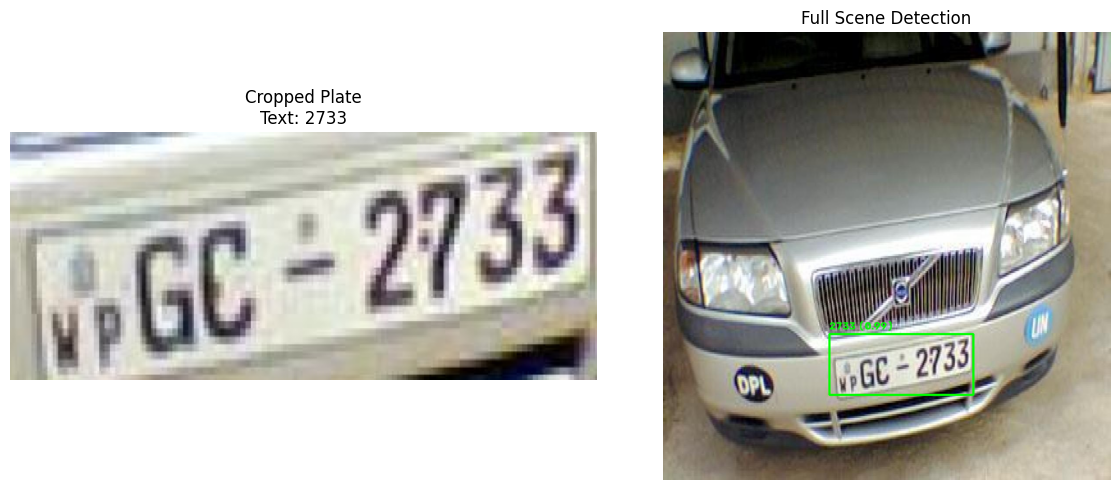

In [2]:
import os
import re
import cv2
import numpy as np
import matplotlib.pyplot as plt
import easyocr
from ultralytics import YOLO

# -------------------------------------------------------------
# 1. SETUP & PATHS
# -------------------------------------------------------------
# Type the target plate number you want to search for:
target_plate = "DL01AB1234"  # Change to any plate number to test matching

# Model and dataset paths
weights_path = r"C:\Users\sandh\PycharmProjects\mlcore\open model\notebook\runs\detect\runs\detect\plate_detector\weights\best.pt"
test_images_dir = r"C:\Users\sandh\PycharmProjects\mlcore\open model\dataset\ANPR.v2i.yolov8\test\images"

# Load models on your RTX 4050 GPU
plate_detector = YOLO(weights_path)
ocr_reader = easyocr.Reader(['en'], gpu=True)

# -------------------------------------------------------------
# 2. HELPER FUNCTIONS
# -------------------------------------------------------------
def clean_text(raw_text):
    """Normalizes text by making it uppercase and removing spaces/symbols."""
    if not raw_text:
        return ""
    return re.sub(r'[^A-Z0-9]', '', raw_text.upper())

def make_plate_variants(crop_bgr):
    """Creates enhanced versions of the plate crop for reliable reading."""
    # Scale to fixed height so character strokes are clear
    h, w = crop_bgr.shape[:2]
    new_h = 100
    new_w = int(new_h * (w / float(h)))
    resized = cv2.resize(crop_bgr, (new_w, new_h), interpolation=cv2.INTER_CUBIC)

    # 1. Grayscale
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # 2. CLAHE (boosts contrast on faint letters)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    contrast = clahe.apply(gray)

    # 3. Bilateral filter (smooths camera noise while keeping edges sharp)
    filtered = cv2.bilateralFilter(contrast, 9, 75, 75)

    return [gray, contrast, filtered]

# -------------------------------------------------------------
# 3. RUN INFERENCE ON TEST IMAGE
# -------------------------------------------------------------
# Grab the first image from your test folder
all_test_images = [f for f in os.listdir(test_images_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
sample_file = all_test_images[0]
sample_path = os.path.join(test_images_dir, sample_file)

frame = cv2.imread(sample_path)

# Predict plate bounding box
results = plate_detector.predict(source=frame, conf=0.35, device=0, verbose=False)[0]

if len(results.boxes) == 0:
    print("No plates found in this test image.")
else:
    for box in results.boxes:
        # Get coordinates and detector confidence
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        det_conf = float(box.conf[0].cpu().numpy())

        # Crop the plate
        plate_crop = frame[y1:y2, x1:x2]

        # Try OCR across enhanced variants and pick the most confident read
        variants = make_plate_variants(plate_crop)
        best_text = ""
        best_ocr_conf = 0.0

        for var in variants:
            ocr_out = ocr_reader.readtext(
                var,
                allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789',
                detail=1
            )
            for _, text, conf in ocr_out:
                cleaned = clean_text(text)
                if len(cleaned) >= 4 and conf > best_ocr_conf:
                    best_ocr_conf = float(conf)
                    best_text = cleaned

        print(f"File: {sample_file}")
        print(f"Plate BBox: [{x1}, {y1}, {x2}, {y2}] | Detect Conf: {det_conf:.2f}")
        print(f"Recognized Number: '{best_text}' | OCR Conf: {best_ocr_conf:.2f}")

        # Compare with target
        clean_target = clean_text(target_plate)
        is_target = bool(clean_target and clean_target in best_text)

        if is_target:
            print("\n>>> TARGET VEHICLE FOUND! <<<")
            box_color = (0, 0, 255)  # Red for target match
            label = f"TARGET FOUND: {best_text}"
        else:
            box_color = (0, 255, 0)  # Green for normal detection
            label = f"{best_text} ({best_ocr_conf:.2f})"

        # Draw on display image
        display_frame = frame.copy()
        cv2.rectangle(display_frame, (x1, y1), (x2, y2), box_color, 3)
        cv2.putText(display_frame, label, (x1, max(30, y1 - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, box_color, 2)

        # Display side-by-side plot
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"Cropped Plate\nText: {best_text}")
        axes[0].axis("off")

        axes[1].imshow(cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB))
        axes[1].set_title("Full Scene Detection")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

In [3]:
import os
import re
import cv2
import pandas as pd
import numpy as np
import easyocr
from ultralytics import YOLO

# 1. Paths
weights_path = r"C:\Users\sandh\PycharmProjects\mlcore\open model\notebook\runs\detect\runs\detect\plate_detector\weights\best.pt"
test_images_dir = r"C:\Users\sandh\PycharmProjects\mlcore\open model\dataset\ANPR.v2i.yolov8\test\images"

# Load models
plate_detector = YOLO(weights_path)
ocr_reader = easyocr.Reader(['en'], gpu=True)

# 2. Helper functions with box padding
def clean_text(raw_text):
    if not raw_text:
        return ""
    return re.sub(r'[^A-Z0-9]', '', raw_text.upper())

def get_enhanced_variants(crop_bgr):
    h, w = crop_bgr.shape[:2]
    if h == 0 or w == 0:
        return []

    # Scale up height to 100px
    target_h = 100
    target_w = int(target_h * (w / float(h)))
    resized = cv2.resize(crop_bgr, (target_w, target_h), interpolation=cv2.INTER_CUBIC)

    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8)).apply(gray)
    filtered = cv2.bilateralFilter(clahe, 9, 75, 75)

    return [resized, gray, clahe, filtered]

# 3. Process all images
all_test_images = [f for f in os.listdir(test_images_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
results_data = []

print(f"Running inference across {len(all_test_images)} test images...")

for idx, img_file in enumerate(all_test_images):
    img_path = os.path.join(test_images_dir, img_file)
    frame = cv2.imread(img_path)
    if frame is None:
        continue

    h_img, w_img = frame.shape[:2]
    preds = plate_detector.predict(source=frame, conf=0.35, device=0, verbose=False)[0]

    if len(preds.boxes) == 0:
        results_data.append({
            "File": img_file,
            "Plate_Found": False,
            "Recognized_Text": "",
            "YOLO_Conf": 0.0,
            "OCR_Conf": 0.0
        })
        continue

    for box in preds.boxes:
        bx1, by1, bx2, by2 = map(int, box.xyxy[0].cpu().numpy())
        det_conf = float(box.conf[0].cpu().numpy())

        # Add a 6% padding around the crop so edge letters are not clipped
        pad_x = int((bx2 - bx1) * 0.06)
        pad_y = int((by2 - by1) * 0.06)

        x1 = max(0, bx1 - pad_x)
        y1 = max(0, by1 - pad_y)
        x2 = min(w_img - 1, bx2 + pad_x)
        y2 = min(h_img - 1, by2 + pad_y)

        plate_crop = frame[y1:y2, x1:x2]
        variants = get_enhanced_variants(plate_crop)

        best_plate_str = ""
        best_ocr_conf = 0.0

        for var in variants:
            # paragraph=False reads all detected text blocks in the crop
            ocr_out = ocr_reader.readtext(var, allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789', detail=1)

            # Combine all pieces found inside the crop (helps with multi-line or spaced plates)
            combined_text = "".join([clean_text(item[1]) for item in ocr_out])
            avg_conf = np.mean([item[2] for item in ocr_out]) if ocr_out else 0.0

            if len(combined_text) >= 4 and avg_conf > best_ocr_conf:
                best_ocr_conf = float(avg_conf)
                best_plate_str = combined_text

        results_data.append({
            "File": img_file,
            "Plate_Found": True,
            "Recognized_Text": best_plate_str,
            "YOLO_Conf": round(det_conf, 2),
            "OCR_Conf": round(best_ocr_conf, 2)
        })

# 4. Display as DataFrame table
df = pd.DataFrame(results_data)
print("\n--- Testing Complete ---")
print(f"Total Detected: {df['Plate_Found'].sum()} / {len(df)}")
df.head(20)

Running inference across 64 test images...

--- Testing Complete ---
Total Detected: 69 / 70


,File,Plate_Found,Recognized_Text,YOLO_Conf,OCR_Conf
0,105_jpg.rf.19add5d0fb70224447057d2ea8a4eea6.jpg,True,GC2733,0.77,0.97
1,124_jpg.rf.47cb266f845ec0579fd51e5e63fc1be8.jpg,True,PCMLD,0.76,0.40
2,130_jpg.rf.0847c685a66d5ce18485ef7b49e85668.jpg,True,18187,0.77,0.40
3,133_jpg.rf.fca4ddb34ba6aa29930cea882d67f4b8.jpg,True,MKG14288,0.78,0.69
4,170_jpg.rf.a60783258f5e3c9e5f0270df64cac4e1.jpg,True,EPHZ5252,0.73,0.46
5,17_jpg.rf.7a345ee2750ab27adbe7beec0e900d60.jpg,True,EHL2358,0.76,0.93
6,181_jpg.rf.27d78ee7d8d7596391cfca16d977b9ef.jpg,True,GA8069,0.83,0.89
7,184_jpg.rf.84505c83929d95149161351d86631759.jpg,True,9162CBB,0.82,0.67
8,190_jpg.rf.2954c93e8df7cebda45e944a707925dd.jpg,True,FPCBA1247,0.83,0.52
9,191_jpg.rf.0dafbfa5d1be4294cf8644726b58a935.jpg,True,MPCAL3512,0.78,0.73


In [4]:
# Show all rows without truncation
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', None)

# Filter to see only the detections where text was recognized
df[['File', 'Plate_Found', 'Recognized_Text', 'YOLO_Conf', 'OCR_Conf']].head(25)

,File,Plate_Found,Recognized_Text,YOLO_Conf,OCR_Conf
0,105_jpg.rf.19add5d0fb70224447057d2ea8a4eea6.jpg,True,GC2733,0.77,0.97
1,124_jpg.rf.47cb266f845ec0579fd51e5e63fc1be8.jpg,True,PCMLD,0.76,0.40
2,130_jpg.rf.0847c685a66d5ce18485ef7b49e85668.jpg,True,18187,0.77,0.40
3,133_jpg.rf.fca4ddb34ba6aa29930cea882d67f4b8.jpg,True,MKG14288,0.78,0.69
4,170_jpg.rf.a60783258f5e3c9e5f0270df64cac4e1.jpg,True,EPHZ5252,0.73,0.46
5,17_jpg.rf.7a345ee2750ab27adbe7beec0e900d60.jpg,True,EHL2358,0.76,0.93
6,181_jpg.rf.27d78ee7d8d7596391cfca16d977b9ef.jpg,True,GA8069,0.83,0.89
7,184_jpg.rf.84505c83929d95149161351d86631759.jpg,True,9162CBB,0.82,0.67
8,190_jpg.rf.2954c93e8df7cebda45e944a707925dd.jpg,True,FPCBA1247,0.83,0.52
9,191_jpg.rf.0dafbfa5d1be4294cf8644726b58a935.jpg,True,MPCAL3512,0.78,0.73


In [5]:
# Check if any image failed detection or OCR
missed_or_blank = df[(df['Plate_Found'] == False) | (df['Recognized_Text'] == '')]
print(f"Total blank or missed: {len(missed_or_blank)}")
missed_or_blank

Total blank or missed: 3


,File,Plate_Found,Recognized_Text,YOLO_Conf,OCR_Conf
24,Cars162_png.rf.5c9da5e94ce4c3658a3320fbe4321a9b.jpg,False,,0.00,0.0
32,Cars290_png.rf.26889ea3399469e43351f09d72708224.jpg,True,,0.69,0.0
36,Cars30_png.rf.48edd9318b897091f01839e987e8fc24.jpg,True,,0.68,0.0


In [2]:
import os
import re
import cv2
import numpy as np
from collections import Counter
from ultralytics import YOLO
import easyocr
from IPython.display import display, Image, clear_output

# -------------------------------------------------------------
# 1. CONFIGURATION
# -------------------------------------------------------------
VIDEO_SOURCE = r"C:\Users\sandh\PycharmProjects\mlcore\open model\dataset\WhatsApp Video 2026-09-12 at 4.35.30 PM.mp4"
TARGET_PLATE = "KA02MN1826"  # Set target plate or leave empty to display all
WEIGHTS_PATH = r"C:\Users\sandh\PycharmProjects\mlcore\open model\notebook\runs\detect\runs\detect\plate_detector\weights\best.pt"
OCR_EVERY_N_FRAMES = 5
DISPLAY_EVERY_N_FRAMES = 2  # Skip frames in UI display to keep notebook responsive

# -------------------------------------------------------------
# 2. LOAD MODELS & BUFFERS
# -------------------------------------------------------------
vehicle_model = YOLO("yolov8n.pt")
plate_model = YOLO(WEIGHTS_PATH)
ocr_reader = easyocr.Reader(['en'], gpu=True)

plate_history = {}
stable_plates = {}

def clean_text(raw_text):
    if not raw_text:
        return ""
    return re.sub(r'[^A-Z0-9]', '', raw_text.upper())

target_clean = clean_text(TARGET_PLATE)

# -------------------------------------------------------------
# 3. PROCESS VIDEO STREAM
# -------------------------------------------------------------
cap = cv2.VideoCapture(VIDEO_SOURCE)
frame_count = 0

print("Processing video... Click 'Interrupt Kernel' (Stop button) anytime to halt.")

try:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            print("\nPlayback completed.")
            break

        frame_count += 1
        h_img, w_img = frame.shape[:2]

        # 1. Track vehicles via ByteTrack
        v_results = vehicle_model.track(
            frame,
            classes=[2, 3, 5, 7],
            tracker="bytetrack.yaml",
            persist=True,
            conf=0.35,
            device=0,
            verbose=False
        )[0]

        tracked_vehicles = []
        if v_results.boxes and v_results.boxes.id is not None:
            boxes = v_results.boxes.xyxy.cpu().numpy().astype(int)
            track_ids = v_results.boxes.id.cpu().numpy().astype(int)
            for b, tid in zip(boxes, track_ids):
                tracked_vehicles.append({"id": int(tid), "box": b})

        # 2. Detect plates
        p_results = plate_model.predict(
            frame,
            conf=0.35,
            device=0,
            verbose=False
        )[0]

        should_run_ocr = (frame_count % OCR_EVERY_N_FRAMES == 0) and (len(p_results.boxes) > 0)

        for pbox in p_results.boxes:
            px1, py1, px2, py2 = map(int, pbox.xyxy[0].cpu().numpy())
            p_cx = (px1 + px2) // 2
            p_cy = (py1 + py2) // 2

            parent_v_id = None
            for veh in tracked_vehicles:
                vx1, vy1, vx2, vy2 = veh["box"]
                if vx1 <= p_cx <= vx2 and vy1 <= p_cy <= vy2:
                    parent_v_id = veh["id"]
                    break

            if should_run_ocr and parent_v_id is not None:
                p_crop = frame[max(0, py1):min(h_img, py2), max(0, px1):min(w_img, px2)]
                if p_crop.size > 0:
                    gray = cv2.cvtColor(p_crop, cv2.COLOR_BGR2GRAY)
                    ocr_out = ocr_reader.readtext(
                        gray,
                        allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789',
                        detail=1
                    )
                    detected_str = "".join([clean_text(item[1]) for item in ocr_out])

                    if len(detected_str) >= 4:
                        if parent_v_id not in plate_history:
                            plate_history[parent_v_id] = []
                        plate_history[parent_v_id].append(detected_str)

                        most_common = Counter(plate_history[parent_v_id]).most_common(1)[0][0]
                        stable_plates[parent_v_id] = most_common

            cv2.rectangle(frame, (px1, py1), (px2, py2), (255, 165, 0), 2)

        # 3. Draw Vehicle Boxes & Banners
        for veh in tracked_vehicles:
            vx1, vy1, vx2, vy2 = veh["box"]
            vid = veh["id"]
            plate_str = stable_plates.get(vid, "")

            is_target = bool(target_clean and plate_str and target_clean in plate_str)

            if is_target:
                box_color = (0, 0, 255)
                line_w = 4
                banner_text = f"TARGET FOUND! ID:{vid} [{plate_str}]"
                cv2.rectangle(frame, (vx1, max(0, vy1 - 40)), (vx1 + 380, vy1), (0, 0, 255), -1)
                cv2.putText(frame, banner_text, (vx1 + 8, vy1 - 12),
                            cv2.FONT_HERSHEY_DUPLEX, 0.65, (255, 255, 255), 2)
            else:
                box_color = (0, 255, 0)
                line_w = 2
                label_text = f"ID:{vid} {plate_str}" if plate_str else f"ID:{vid}"
                cv2.putText(frame, label_text, (vx1, max(20, vy1 - 8)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, box_color, 2)

            cv2.rectangle(frame, (vx1, vy1), (vx2, vy2), box_color, line_w)

        # 4. Display inline inside Jupyter Notebook
        if frame_count % DISPLAY_EVERY_N_FRAMES == 0:
            # Downscale slightly for smooth playback inside notebook
            preview = cv2.resize(frame, (800, int(800 * (h_img / float(w_img)))))
            _, buffer = cv2.imencode('.jpeg', preview, [cv2.IMWRITE_JPEG_QUALITY, 75])

            clear_output(wait=True)
            display(Image(data=buffer.tobytes()))

finally:
    cap.release()
    print("Stream cleanly released.")


Playback completed.
Stream cleanly released.
